In [1]:
"""
=======================
Benchmarking with MOABB
=======================

This example shows how to use MOABB to benchmark a set of pipelines
on all available datasets. For this example, we will use only one
dataset to keep the computation time low, but this benchmark is designed
to easily scale to many datasets.
"""

# Authors: Sylvain Chevallier <sylvain.chevallier@universite-paris-saclay.fr>
#
# License: BSD (3-clause)

import matplotlib.pyplot as plt

from moabb import benchmark, set_log_level
from moabb.analysis.plotting import score_plot
from moabb.paradigms import LeftRightImagery


set_log_level("info")

In [2]:
###############################################################################
# Loading the pipelines
# ---------------------
#
# The ML pipelines used in benchmark are defined in YAML files, following a
# simple format. It simplifies sharing and reusing pipelines across benchmarks,
# reproducing state-of-the-art results.
#
# MOABB comes with complete list of pipelines that cover most of the successful
# approaches in the literature. You can find them in the
# `pipelines folder <https://github.com/NeuroTechX/moabb/tree/develop/pipelines>`_.
# For this example, we will use a folder with only 2 pipelines, to keep the
# computation time low.
#
# This is an example of a pipeline defined in YAML, defining on which paradigms it
# can be used, the original publication, and the steps to perform using a
# scikit-learn API. In this case, a CSP + SVM pipeline, the covariance are estimated
# to compute a CSP filter and then a linear SVM is trained on the CSP filtered
# signals.

with open("sample_pipelines/csp_svm.yml", "r") as f:
    lines = f.readlines()
    for line in lines:
        print(line, end="")

name: CSP + SVM
paradigms:
  - LeftRightImagery

citations:
  - https://doi.org/10.1007/BF01129656
  - https://doi.org/10.1109/MSP.2008.4408441

pipeline:
  - name: Covariances
    from: pyriemann.estimation
    parameters:
      estimator: oas

  - name: CSP
    from: pyriemann.spatialfilters
    parameters:
      nfilter: 6

  - name: SVC
    from: sklearn.svm
    parameters:
      kernel: "linear"


In [3]:
###############################################################################
# The ``sample_pipelines`` folder contains a second pipeline, a logistic regression
# performed in the tangent space using Riemannian geometry.
#
# Selecting the datasets (optional)
# ---------------------------------
#
# If you want to limit your benchmark on a subset of datasets, you can use the
# ``include_datasets`` and ``exclude_datasets`` arguments. You will need either
# to provide the dataset's object, or a the dataset's code. To get the list of
# available dataset's code for a given paradigm, you can use the following command:

paradigm = LeftRightImagery()
for d in paradigm.datasets:
    print(d.code)

BNCI2014-001
BNCI2014-004
Beetl2021-A
Beetl2021-B
Cho2017
Dreyer2023
Dreyer2023A
Dreyer2023B
Dreyer2023C
GrosseWentrup2009
Lee2019-MI
Liu2024
PhysionetMotorImagery
Schirrmeister2017
Shin2017A
Stieger2021
Weibo2014
Zhou2016


In [9]:
###############################################################################
# In this example, we will use only the last dataset, 'Zhou2016'.
#
# Running the benchmark
# ---------------------
#
# The benchmark is run using the ``benchmark`` function. You need to specify the
# folder containing the pipelines to use, the kind of evaluation and the paradigm
# to use. By default, the benchmark will use all available datasets for all
# paradigms listed in the pipelines. You could restrict to specific evaluation and
# paradigm using the ``evaluations`` and ``paradigms`` arguments.
#
# To save computation time, the results are cached. If you want to re-run the
# benchmark, you can set the ``overwrite`` argument to ``True``.
#
# It is possible to indicate the folder to cache the results and the one to save
# the analysis & figures. By default, the results are saved in the ``results``
# folder, and the analysis & figures are saved in the ``benchmark`` folder.

results = benchmark(
    pipelines="./sample_pipelines/",
    evaluations=["WithinSession"],
    paradigms=["LeftRightImagery"],
    include_datasets=["Zhou2016", "Weibo2014"],
    results="./results/",
    overwrite=False,
    plot=False,
    output="./benchmark/",
)

The paradigms being run are dict_keys(['LeftRightImagery'])
Datasets considered for LeftRightImagery paradigm ['Weibo2014', 'Zhou2016']


Weibo2014-WithinSession:   0%|          | 0/10 [00:00<?, ?it/s]/Users/sopsahl/nta/thesis/projects/moabb/moabb/datasets/download.py:60: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_WEIBO_PATH"
  set_config(key, get_config("MNE_DATA"))

  0%|                                              | 0.00/1.76G [00:00<?, ?B/s]
  0%|                                    | 71.7k/1.76G [00:00<1:05:13, 449kB/s]
  0%|                                      | 283k/1.76G [00:00<23:44, 1.23MB/s]
  0%|                                      | 664k/1.76G [00:00<13:03, 2.24MB/s]
  0%|                                     | 1.31M/1.76G [00:00<07:49, 3.74MB/s]
  0%|                                     | 2.14M/1.76G [00:00<05:32, 5.27MB/s]
  0%|                                     | 2.69M/1.76G [00:00<10:52, 2.69MB/s]
  0%|▏                                    | 6.26M/1.76G [00:01<03:16, 8.92MB/s]
  0%|▏                                    | 7.70M/1.76G [00:01<03:59, 7.30MB/s]
  1%|▏                    

     dataset     evaluation          pipeline  avg score
0  Weibo2014  WithinSession  Tangent Space LR   0.835957
1  Weibo2014  WithinSession         CSP + SVM   0.801518
2   Zhou2016  WithinSession  Tangent Space LR   0.941601
3   Zhou2016  WithinSession         CSP + SVM   0.932315


2025-12-29 14:38:31,736 WARNING MainThread moabb.analysis.plotting Dataset names are too similar, turning off name shortening
/Users/sopsahl/nta/thesis/projects/moabb/moabb/analysis/plotting.py:76: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sea.stripplot(


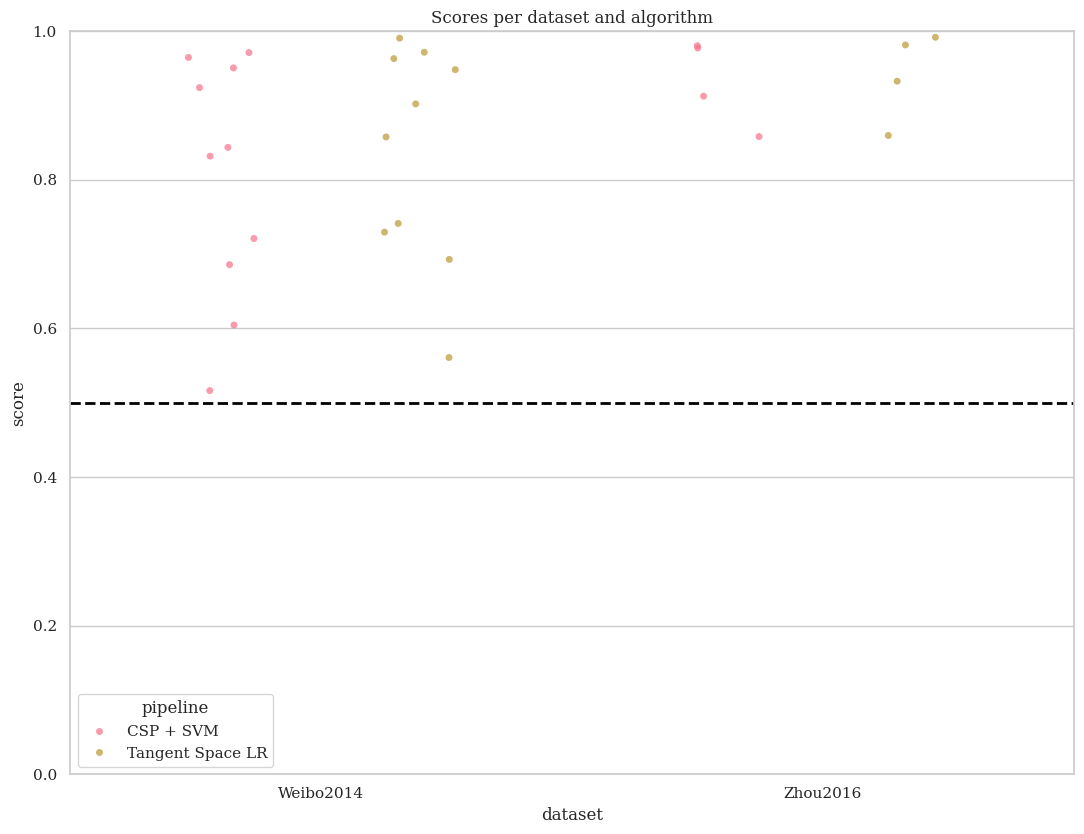

In [11]:
###############################################################################
# Benchmark prints a summary of the results. Detailed results are saved in a
# pandas dataframe, and can be used to generate figures. The analysis & figures
# are saved in the ``benchmark`` folder.

score_plot(results)
plt.show()
